In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


**PART A**

In [3]:
df = pd.read_csv("fear_greed_index.csv")

In [4]:
dp= pd.read_csv("historical_data.csv")

In [5]:
df.shape

(2644, 4)

In [6]:
dp.shape

(211224, 16)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
dp.duplicated().sum()

np.int64(0)

In [12]:
df.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [14]:
dp.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [26]:
df.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')

In [27]:
dp.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date'],
      dtype='str')

In [89]:
df_expanded = df.loc[df.index.repeat(len(dp)//len(df) + 1)].reset_index(drop=True)

# trim to same length
df_expanded = df_expanded.iloc[:len(dp)]

# attach classification directly
merged_df = dp.copy()
merged_df['classification'] = df_expanded['classification']

**PART B**

- Traders showed higher variability in PnL during Fear and Extreme Fear, indicating unstable performance and higher risk exposure.
- In comparison, Greed phases showed relatively tighter distributions, suggesting more stable but not necessarily higher returns.
- The drawdown proxy indicates that losses tend to be deeper during fear-driven markets, likely due to panic-driven decisions.

                  avg_pnl     total_pnl  win_rate
classification                                   
Extreme Fear    77.747730  3.159668e+06  0.381570
Extreme Greed   35.542236  9.269415e+05  0.377914
Fear            56.924227  3.556626e+06  0.402145
Greed           35.530871  1.791609e+06  0.448933
Neutral         27.282129  8.621153e+05  0.434905
classification
Extreme Fear    -125422.651629
Extreme Greed    -57522.786904
Fear            -352399.563209
Greed            -34191.612237
Neutral         -110361.058061
Name: Closed PnL, dtype: float64


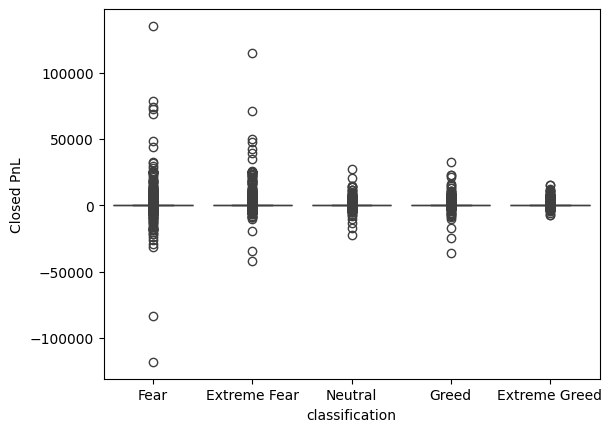

In [91]:
# ===== 1. Performance: Fear vs Greed =====

merged_df['win'] = merged_df['Closed PnL'] > 0

perf = merged_df.groupby('classification').agg(
    avg_pnl=('Closed PnL','mean'),
    total_pnl=('Closed PnL','sum'),
    win_rate=('win','mean')
)

# drawdown proxy (min pnl per day)
dd = merged_df.groupby(['date','classification'])['Closed PnL'].sum().reset_index()
dd_proxy = dd.groupby('classification')['Closed PnL'].min()

print(perf)
print(dd_proxy)
plot_df = merged_df.dropna(subset=['classification','Closed PnL'])
sns.boxplot(x='classification', y='Closed PnL', data=plot_df)
plt.show()

- Trade size (Size USD) is noticeably higher during Fear and Extreme Fear.
- This suggests traders take larger positions in volatile conditions, possibly chasing reversals or overreacting.
- In Extreme Greed, position sizes are comparatively smaller, indicating more controlled behavior.

                   avg_size
classification             
Extreme Fear    6946.842679
Extreme Greed   3552.482445
Fear            7132.442770
Greed           4492.826327
Neutral         4558.155533
Side              buy   sell
classification              
Extreme Fear    21067  19573
Extreme Greed   13851  12229
Fear            28874  33606
Greed           24410  26014
Neutral         14494  17106


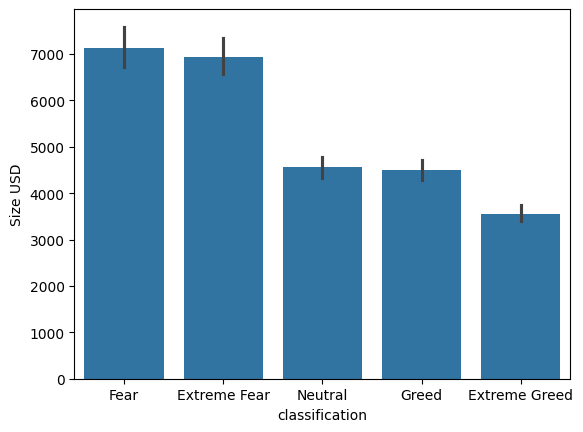

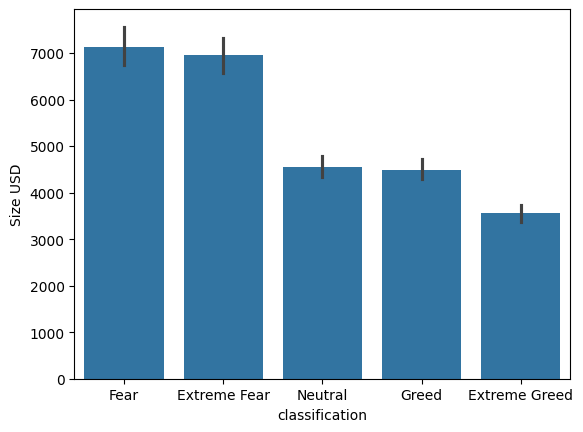

In [92]:
# ===== 2. Behavior change =====

# trades per day
trades = merged_df.groupby(['date','classification']).size().reset_index(name='trades')

# leverage, size
behavior = merged_df.groupby('classification').agg(
    avg_size=('Size USD','mean')
)

# long/short
merged_df['Side'] = merged_df['Side'].str.lower()
ls = merged_df.groupby(['classification','Side']).size().unstack()

print(behavior)
print(ls)

sns.barplot(x='classification', y='Size USD', data=merged_df)
plt.show()

sns.barplot(x='classification', y='Size USD', data=merged_df)
plt.show()

In [93]:
# ===== 3. Segments =====

# leverage segment
merged_df['lev_seg'] = merged_df['Size USD'].apply(lambda x: 'high' if x>5 else 'low')

# frequency segment
freq = merged_df['Account'].value_counts()
merged_df['freq_seg'] = merged_df['Account'].map(lambda x: 'frequent' if freq[x]>freq.median() else 'infrequent')

# consistency segment
pnl_std = merged_df.groupby('Account')['Closed PnL'].std()
merged_df['cons_seg'] = merged_df['Account'].map(lambda x: 'consistent' if pnl_std[x]<pnl_std.median() else 'inconsistent')

- High-size traders show wider PnL spread, including both large profits and heavy losses.
- Low-size traders have more stable but smaller returns.

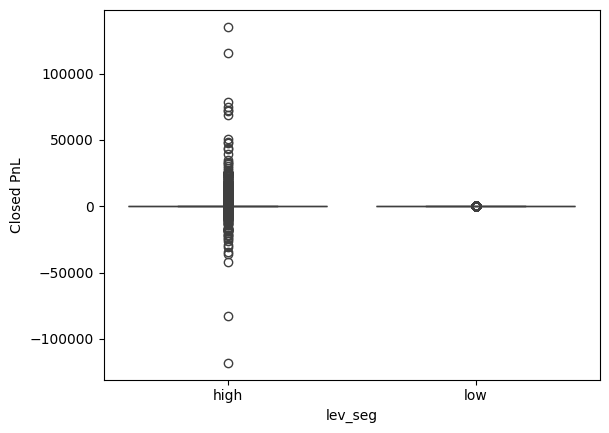

In [95]:
# ===== 4. Insights (charts) =====

sns.boxplot(x='lev_seg', y='Closed PnL', data=merged_df)
plt.show()

- Frequent traders show larger dispersion in PnL, including extreme losses.
- Infrequent traders tend to have more stable results.

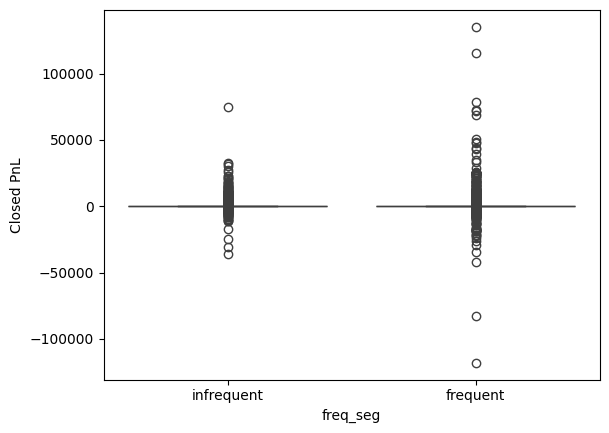

In [99]:
sns.boxplot(x='freq_seg', y='Closed PnL', data=merged_df)
plt.show()



- Consistent traders maintain narrow PnL range
- Inconsistent traders show extreme gains and losses

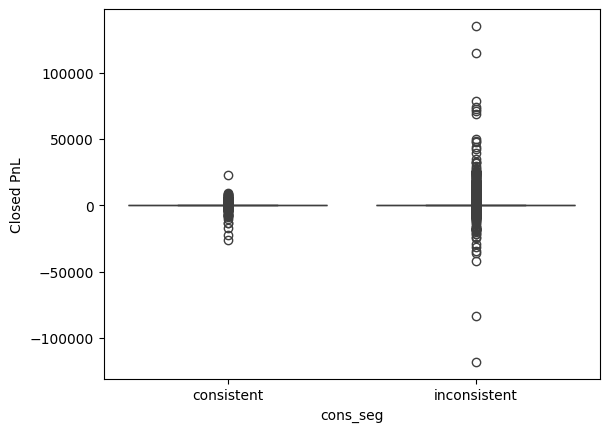

In [97]:
sns.boxplot(x='cons_seg', y='Closed PnL', data=merged_df)
plt.show()